In [2]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"
import torch
import torch.nn.functional as F

In [3]:
import matplotlib.pyplot as plt
%matplotlib inline

In [4]:
words = open("files/names.txt").read().splitlines()
words[:5]

['emma', 'olivia', 'ava', 'isabella', 'sophia']

In [5]:
len(words)

32033

In [6]:
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0 
itos = {i:s for s,i in stoi.items()}

In [7]:
block_size = 3 # context lenght: how many characters do we take to predict the next one     
X,Y = [], []
for w in words:

    # print(w)
    context = [0] * block_size
    for ch in w + '.':
        ix = stoi[ch]
        X.append(context)
        Y.append(ix)
        # print(context)
        # print(''.join(itos[i] for i in context), "--->",itos[ix])
        context = context[1:] + [ix] # crop and update
        
X = torch.tensor(X)
Y = torch.tensor(Y)


In [8]:
def build_dataset(words):
    block_size = 3 # context lenght: how many characters do we take to predict the next one     
    X,Y = [], []
    for w in words:

        # print(w)
        context = [0] * block_size
        for ch in w + '.':
            ix = stoi[ch]
            X.append(context)
            Y.append(ix)
            # print(context)
            # print(''.join(itos[i] for i in context), "--->",itos[ix])
            context = context[1:] + [ix] # crop and update
            
    X = torch.tensor(X)
    Y = torch.tensor(Y)
    print(X.shape,Y.shape)
    return X,Y 


import random 
random.seed(42)
random.shuffle(words)
n1 = int(0.8*len(words))
n2 = int(0.9*len(words))

Xtr,Ytr = build_dataset(words[:n1])
Xdev,Ydev = build_dataset(words[n1:n2])
Xte,Yte = build_dataset(words[n2:])

torch.Size([182625, 3]) torch.Size([182625])
torch.Size([22655, 3]) torch.Size([22655])
torch.Size([22866, 3]) torch.Size([22866])


In [9]:
len(words)-n2

3204

In [10]:
X.shape,X.dtype,Y.shape,Y.dtype

(torch.Size([228146, 3]), torch.int64, torch.Size([228146]), torch.int64)

In [11]:
C = torch.randn((27,2))

In [12]:
C[5]

tensor([ 0.8547, -0.1503])

In [13]:
F.one_hot(torch.tensor(5),27).float() @ C

tensor([ 0.8547, -0.1503])

In [14]:
emb = C[X]
emb.shape

torch.Size([228146, 3, 2])

In [15]:
W1 = torch.randn((6,100))
b1 = torch.randn(100)

In [13]:
emb * W1 + b1

RuntimeError: The size of tensor a (2) must match the size of tensor b (100) at non-singleton dimension 2

In [102]:
torch.cat([emb[:,0,:],emb[:,1,:],emb[:,2,:]],1).shape

torch.Size([228146, 6])

In [103]:
len(torch.unbind(emb,1))

3

In [104]:
torch.cat(torch.unbind(emb,1),1).shape

torch.Size([228146, 6])

In [19]:
emb.view(32,6)[0] == torch.cat(torch.unbind(emb,1),1)[0]

RuntimeError: shape '[32, 6]' is invalid for input of size 1368876

In [20]:
h = torch.tanh(emb.view(32,6) @ W1 + b1)
h,h.shape

RuntimeError: shape '[32, 6]' is invalid for input of size 1368876

In [21]:
W2 = torch.randn((100,27))
b2 = torch.randn(27)
logits = h @ W2 + b2
logits.shape

NameError: name 'h' is not defined

In [22]:
counts = logits.exp()

NameError: name 'logits' is not defined

In [23]:
probs = counts / counts.sum(1,True)
probs.shape

NameError: name 'counts' is not defined

In [24]:
probs[torch.arange(32),Y]

NameError: name 'probs' is not defined

In [25]:
loss = -probs[torch.arange(32),Y].log().mean()
loss

NameError: name 'probs' is not defined

In [16]:
# ---------- More Respected ----------------

In [17]:
Xtr.shape,Ytr.shape # dataset

(torch.Size([182625, 3]), torch.Size([182625]))

In [62]:
g = torch.Generator().manual_seed(2147483647)
C = torch.randn((27,10),generator=g)
W1 = torch.randn((30,200),generator=g)
b1 = torch.randn(200,generator=g)
W2 = torch.randn((200,27),generator=g)
b2 = torch.randn(27,generator=g)
parameters = [C,W1,b1,W2,b2]

In [63]:
sum(p.nelement() for p in parameters)

11897

In [64]:
for p in parameters:
    p.requires_grad = True

In [65]:
lre = torch.linspace(-3,0,1000)
lrs = 10**lre


In [66]:
lri = []
lossi = []
stepi = []

In [74]:

for i in range(50000):

    # minibatch construct
    ix = torch.randint(0,Xtr.shape[0],(32,))

    # Forward Pass
    emb = C[Xtr[ix]] # 32,3,2
    h = torch.tanh(emb.view(-1,30) @ W1 + b1) # (32,100)
    logits = h @ W2 + b2
    loss = F.cross_entropy(logits,Ytr[ix])
    

    # Backward Pass

    for p in parameters:
        p.grad = None

    loss.backward()

    # lr = lrs[i]
    lr = 0.01
    
    for p in parameters:
        p.data += -lr * p.grad

    # lri.append(lr)
    lossi.append(loss.log10().item())
    stepi.append(i)

print(loss.item())


2.261155843734741


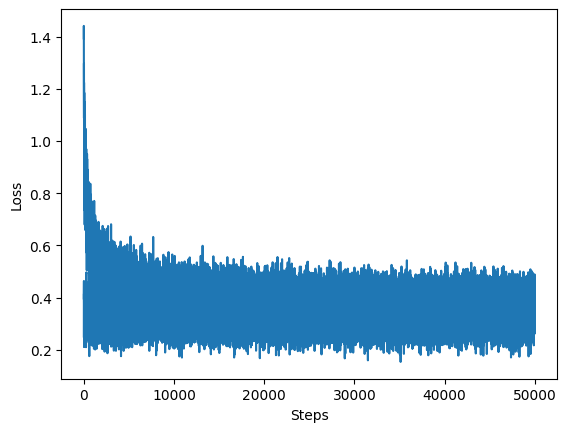

In [75]:
plt.xlabel("Steps")
plt.ylabel("Loss")
plt.plot(stepi,lossi)

In [76]:
# Forward Pass
emb = C[Xtr] # 32,3,2
h = torch.tanh(emb.view(-1,30) @ W1 + b1) # (32,100)
logits = h @ W2 + b2
loss = F.cross_entropy(logits,Ytr)
loss

tensor(2.1698, grad_fn=<NllLossBackward0>)

In [77]:
# Forward Pass
emb = C[Xdev] # 32,3,2
h = torch.tanh(emb.view(-1,30) @ W1 + b1) # (32,100)
logits = h @ W2 + b2
loss = F.cross_entropy(logits,Ydev)
loss

tensor(2.1993, grad_fn=<NllLossBackward0>)

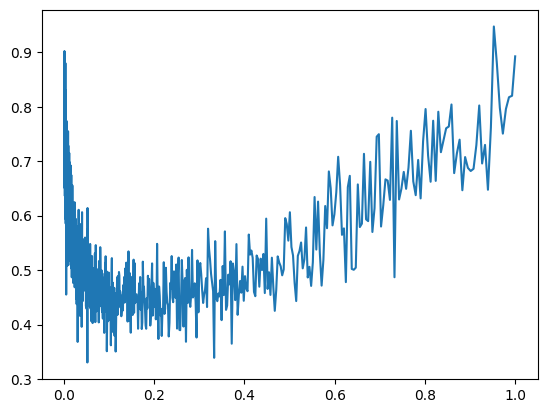

In [36]:
plt.plot(lri,lossi)

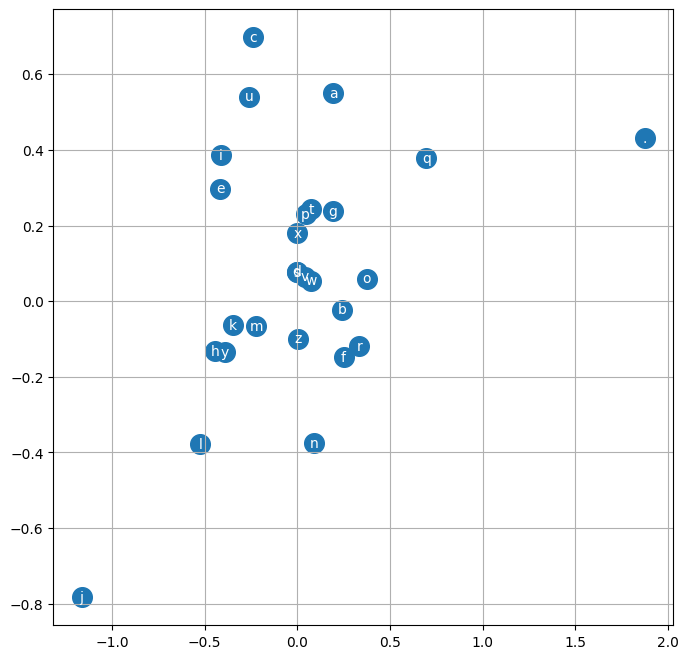

In [78]:
plt.figure(figsize=(8,8))
plt.scatter(C[:,0].data,C[:,1].data,s=200)
for i in range(C.shape[0]):
    plt.text(C[i,0].item(),C[i,1].item(),itos[i],ha="center",va="center",color="white")
plt.grid("minor")

In [ ]:
g = torch.Generator().manual_seed(2147483647 + 10)

for _ in range(20):
    out = []
    context = [0] * block_size # initialize with ....
    while True:
        emb = C[torch.tensor([context])]
        h = torch.tanh(emb.view(1,-1) @ W1 + b1)
        logits = h @ W2 + b2
        probs = torch.softmax(logits,1)
        ix = torch.multinomial(probs,num_samples=1,generator=g).item()
        context = context[1:] + [ix]
        out.append(ix)
        if ix == 0:break

    print(''.join(itos[i] for i in out))
